In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocessing functions

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

##from tensorflow.keras.applications.vgg16 import preprocess_input
#from tensorflow.keras.applications.resnet50 import preprocess_input
#from tensorflow.keras.applications.mobilenet import preprocess_input
#from tensorflow.keras.applications.inception_v3 import preprocess_input
#from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize [0,1]
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

In [3]:
cnn_train_generator = cnn_train_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 6225 images belonging to 11 classes.


In [4]:
cnn_test_datagen = ImageDataGenerator(rescale=1./255)

cnn_test_generator = cnn_test_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Important for evaluation
)

Found 3187 images belonging to 11 classes.


In [5]:
cnn_val_datagen = ImageDataGenerator(rescale=1./255)

cnn_val_generator = cnn_val_datagen.flow_from_directory(
    'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1092 images belonging to 11 classes.


In [6]:
import json

# Save class labels
with open("class_indices.json", "w") as f:
    json.dump(cnn_train_generator.class_indices, f)

In [11]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0

import tensorflow as tf

In [8]:
# ================== CNN MODEL ==================
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(len(cnn_train_generator.class_indices),activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_history = cnn_model.fit(
    cnn_train_generator,
    validation_data=cnn_val_generator,
    epochs=15
)

cnn_model.save("CNN_Model.h5")


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 42s 211ms/step - accuracy: 0.2474 - loss: 2.1149 - val_accuracy: 0.3324 - val_loss: 1.8068
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.3582 - loss: 1.7489 - val_accuracy: 0.4973 - val_loss: 1.4246
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - accuracy: 0.4492 - loss: 1.4910 - val_accuracy: 0.6529 - val_loss: 1.0750
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 210ms/step - accuracy: 0.5157 - loss: 1.2652 - val_accuracy: 0.5998 - val_loss: 1.1226
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 210ms/step - accuracy: 0.5684 - loss: 1.1401 - val_accuracy: 0.7491 - val_loss: 0.8283
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.5937 - loss: 1.0665 - val_accuracy: 0.7720 - val_loss: 0.6893
Epoch 7/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 40s 207ms/step - accuracy: 0.6288 - loss: 1.0005 - val_accuracy: 0.7921 - val_loss: 0.6656
Epoch 8/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.6761 - loss: 0

In [10]:
 # Evaluate on test
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(cnn_test_generator)
print("CNN Test Accuracy:", cnn_test_acc)

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8384 - loss: 0.4392
CNN Test Accuracy: 0.8384060263633728


In [12]:
# ================== PRETRAINED MODELS ==================
pretrained_models = {
    "VGG16": (VGG16, vgg16_preprocess),
    "ResNet50": (ResNet50, resnet_preprocess),
    "MobileNet": (MobileNet, mobilenet_preprocess),
    "InceptionV3": (InceptionV3, inception_preprocess),
    "EfficientNetB0": (EfficientNetB0, efficientnet_preprocess)
}


best_acc = 0
best_model = None
best_model_name = None
trained_models = {}

for name, (model_class, preprocess_func) in pretrained_models.items():

    print(f"\nTraining {name}")

    # Generators
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rotation_range=30,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    train_gen = train_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/train',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical'
    )

    val_gen = val_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/val',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical'
    )

    test_gen = test_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    # Model
    base_model = model_class(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128,activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(len(train_gen.class_indices),activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(train_gen, validation_data=val_gen, epochs=15)

    # Fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(train_gen, validation_data=val_gen, epochs=10)

    loss, acc = model.evaluate(test_gen)
    print(f"{name} Accuracy: {acc:.4f}")

    trained_models[name] = model

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name
        model.save("Best_Model.h5")

print("Best Model:", best_model_name)


Training VGG16
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.5995 - loss: 1.4212 - val_accuracy: 0.9332 - val_loss: 0.2773
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.8435 - loss: 0.4592 - val_accuracy: 0.9689 - val_loss: 0.1002
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.8982 - loss: 0.3031 - val_accuracy: 0.9817 - val_loss: 0.0558
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.9169 - loss: 0.2363 - val_accuracy: 0.9835 - val_loss: 0.0611
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9311 - loss: 0.1956 - val_accuracy: 0.9899 - val_loss: 0.0369
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9425 - loss: 0.1619 - val_accuracy: 0.9853 - val_loss: 0.0482
Epoch 7/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 712s 4s/step - accuracy: 0.9499 - loss: 0

VGG16 Accuracy: 0.9984

Training ResNet50
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 400ms/step - accuracy: 0.8082 - loss: 0.6211 - val_accuracy: 0.9689 - val_loss: 0.1094
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 401ms/step - accuracy: 0.9377 - loss: 0.1943 - val_accuracy: 0.9890 - val_loss: 0.0417
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 401ms/step - accuracy: 0.9576 - loss: 0.1370 - val_accuracy: 0.9908 - val_loss: 0.0342
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 402ms/step - accuracy: 0.9643 - loss: 0.1117 - val_accuracy: 0.9881 - val_loss: 0.0338
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 402ms/step - accuracy: 0.9667 - loss: 0.0942 - val_accuracy: 0.9890 - val_loss: 0.0294
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 401ms/step - accuracy: 0.9701 - loss: 0.0852 - val_accuracy: 0.9963 - val_loss: 0.0123
Epoch 7/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s

ResNet50 Accuracy: 0.9991

Training MobileNet
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.7375 - loss: 0.8340 - val_accuracy: 0.9542 - val_loss: 0.1808
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.9222 - loss: 0.2659 - val_accuracy: 0.9789 - val_loss: 0.0767
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.9462 - loss: 0.1694 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.9606 - loss: 0.1281 - val_accuracy: 0.9918 - val_loss: 0.0374
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.9669 - loss: 0.1028 - val_accuracy: 0.9908 - val_loss: 0.0335
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.9720 - loss: 0.0902 - val_accuracy: 0.9945 - val_loss: 0.0265
Epoch 7/15
195/195 ━━━━━━━━━━━━━━━━━━━━

In [16]:
print("\nAll Model Accuracies:")

# CNN (correct)
print("CNN:", cnn_model.evaluate(cnn_test_generator)[1])

# Pretrained models (IMPORTANT FIX)
for name, (model_class, preprocess_func) in pretrained_models.items():

    # recreate SAME test generator used during training
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    test_gen = test_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    acc = trained_models[name].evaluate(test_gen)[1]
    print(f"{name}: {acc:.4f}")


All Model Accuracies:
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8384 - loss: 0.4392
CNN: 0.8384060263633728
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9984 - loss: 0.0074
VGG16: 0.9984
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 329ms/step - accuracy: 0.9991 - loss: 0.0043
ResNet50: 0.9991
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9981 - loss: 0.0089
MobileNet: 0.9981
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - accuracy: 0.9959 - loss: 0.0163
InceptionV3: 0.9959
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9969 - loss: 0.0093
EfficientNetB0: 0.9969


In [17]:
print("Best Model:", best_model_name)

Best Model: ResNet50


In [27]:
class_names = list(cnn_test_generator.class_indices.keys())

class_names

['animal fish',
 'animal fish bass',
 'fish sea_food black_sea_sprat',
 'fish sea_food gilt_head_bream',
 'fish sea_food hourse_mackerel',
 'fish sea_food red_mullet',
 'fish sea_food red_sea_bream',
 'fish sea_food sea_bass',
 'fish sea_food shrimp',
 'fish sea_food striped_red_mullet',
 'fish sea_food trout']

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# ================== CLASS NAMES ==================
class_names = list(cnn_train_generator.class_indices.keys())


# ================== EVALUATION FUNCTION ==================
def evaluate_model(model, test_gen, name):

    print(f"\nEvaluating {name}")

    y_pred = model.predict(test_gen)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred_classes)
    print("Accuracy:", acc)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred_classes,target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    print("\nConfusion Matrix:\n", cm)

    # Plot confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc


Evaluating CNN
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step
Accuracy: 0.8384060244744274

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       520
           1       0.00      0.00      0.00        13
           2       0.90      0.90      0.90       298
           3       0.92      0.46      0.61       305
           4       0.72      0.97      0.82       286
           5       1.00      0.92      0.96       291
           6       0.66      0.88      0.75       273
           7       0.71      0.68      0.69       327
           8       0.96      0.85      0.90       289
           9       0.87      0.70      0.77       293
          10       0.74      1.00      0.85       292

    accuracy                           0.84      3187
   macro avg       0.77      0.76      0.75      3187
weighted avg       0.85      0.84      0.83      3187


Confusion Matrix:
 [[517   0   2   0   0   0   0   0   0   0   1]
 [ 12   

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


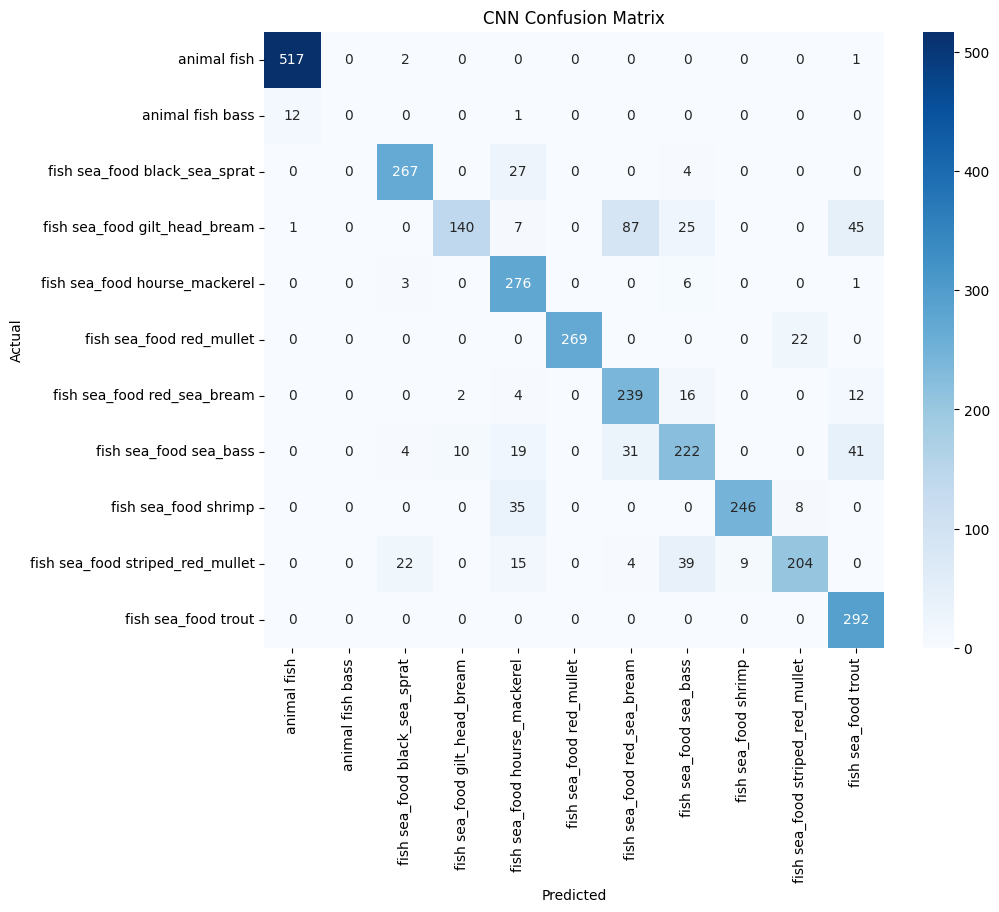

In [31]:
cnn_acc = evaluate_model(cnn_model, cnn_test_generator, "CNN")


Processing VGG16
Found 3187 images belonging to 11 classes.

Evaluating VGG16
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step
Accuracy: 0.998431126451208

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      1.00       520
                animal fish bass       1.00      0.62      0.76        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
           

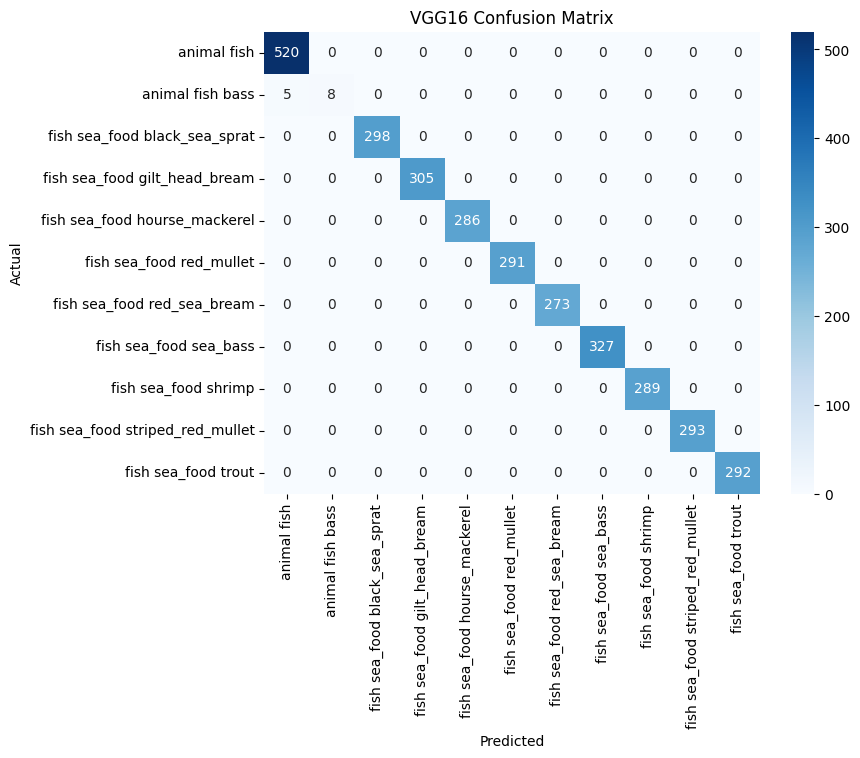


Processing ResNet50
Found 3187 images belonging to 11 classes.

Evaluating ResNet50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step
Accuracy: 0.9990586758707248

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       1.00      1.00      1.00       520
                animal fish bass       0.92      0.85      0.88        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      1.00      1.00       293
  

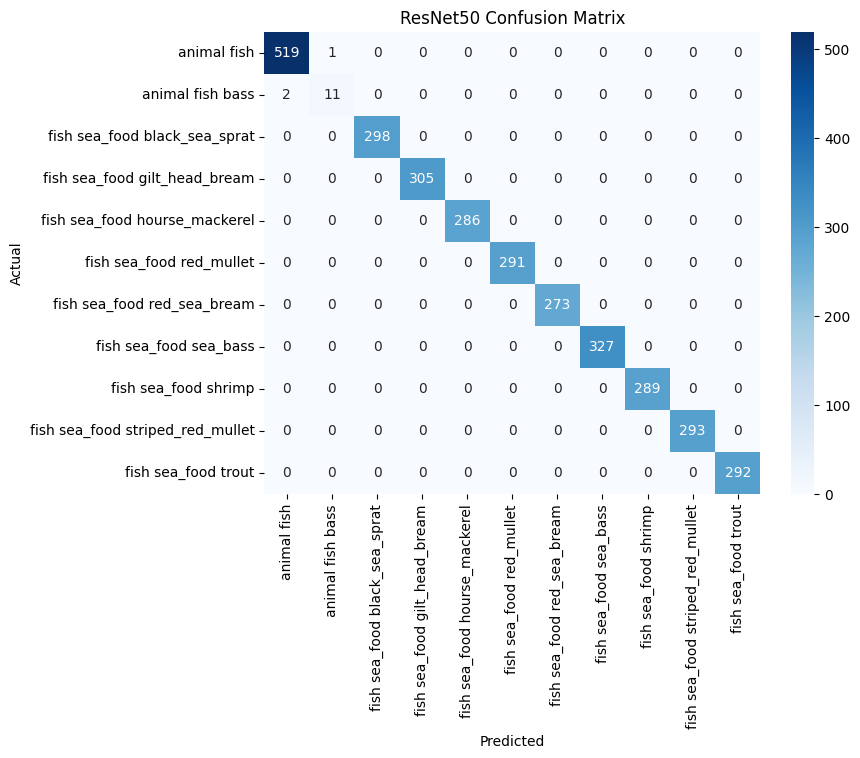


Processing MobileNet
Found 3187 images belonging to 11 classes.

Evaluating MobileNet
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step
Accuracy: 0.9981173517414497

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      1.00       520
                animal fish bass       1.00      0.69      0.82        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      0.99      1.00       293
  

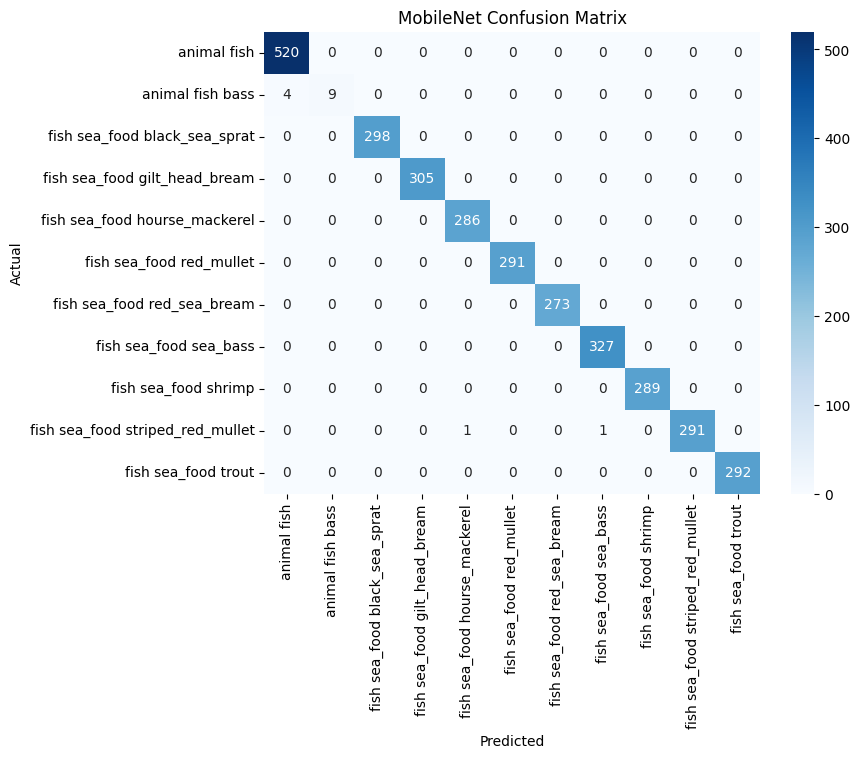


Processing InceptionV3
Found 3187 images belonging to 11 classes.

Evaluating InceptionV3
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step
Accuracy: 0.9959209287731409

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.98      1.00      0.99       520
                animal fish bass       1.00      0.38      0.56        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      0.99      0.99       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       0.99      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.99      0.99      0.99       

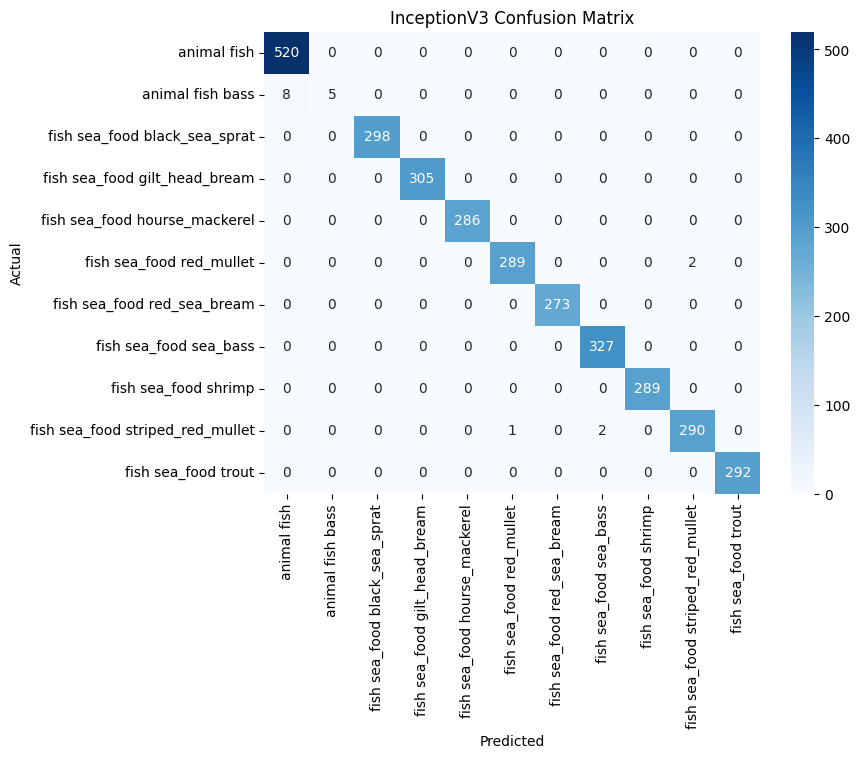


Processing EfficientNetB0
Found 3187 images belonging to 11 classes.

Evaluating EfficientNetB0
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step
Accuracy: 0.996862252902416

Classification Report:

                                  precision    recall  f1-score   support

                     animal fish       0.99      0.99      0.99       520
                animal fish bass       0.90      0.69      0.78        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       0.99      1.00      1.00       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       1.00      1.00      1.00       273
          fish sea_food sea_bass       1.00      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       1.00      1.00      1.00  

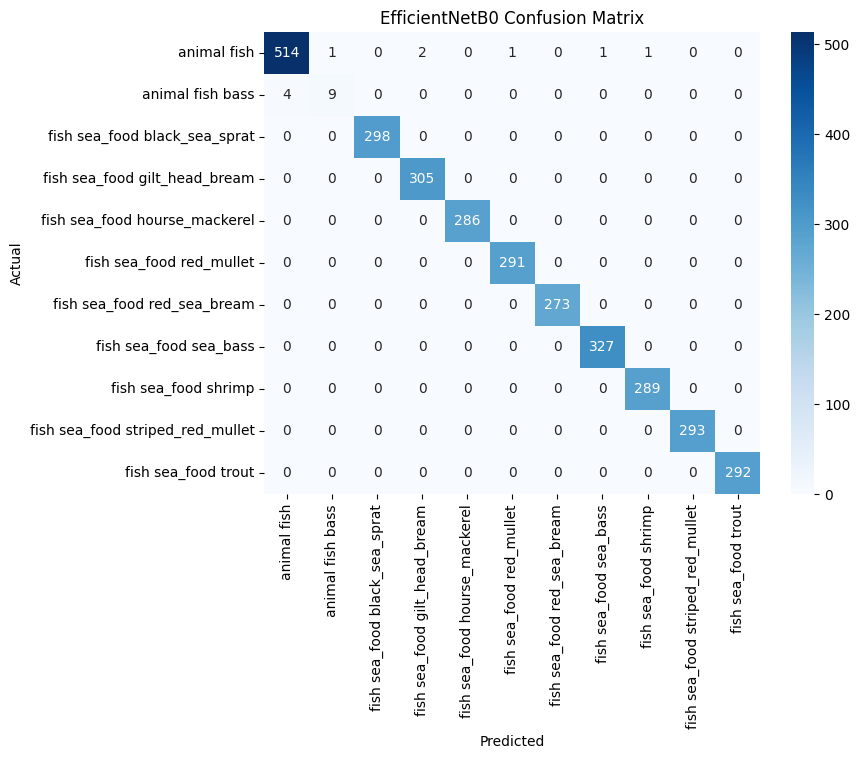

In [35]:
results = {"CNN": cnn_acc}

for name, (model_class, preprocess_func) in pretrained_models.items():

    print(f"\nProcessing {name}")

    # Correct generator per model (VERY IMPORTANT)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    test_gen = test_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    acc = evaluate_model(trained_models[name], test_gen, name)
    results[name] = acc

In [33]:
print("\n===== FINAL ACCURACY COMPARISON =====")

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model} ({results[best_model]:.4f})")


===== FINAL ACCURACY COMPARISON =====
CNN: 0.8384
VGG16: 0.9984
ResNet50: 0.9991
MobileNet: 0.9981
InceptionV3: 0.9959
EfficientNetB0: 0.9969

🏆 Best Model: ResNet50 (0.9991)


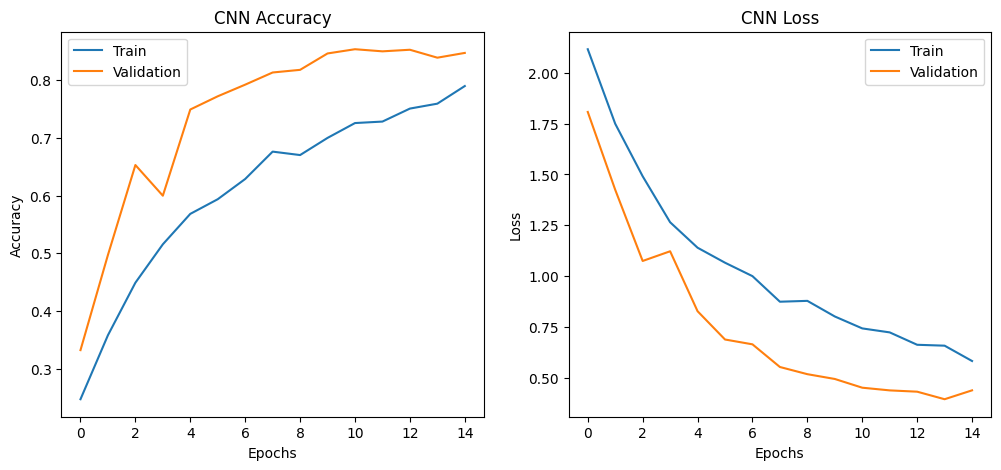

In [36]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8384 - loss: 0.4392
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9984 - loss: 0.0074
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 329ms/step - accuracy: 0.9991 - loss: 0.0043
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9981 - loss: 0.0089
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step - accuracy: 0.9959 - loss: 0.0163
Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.9969 - loss: 0.0093


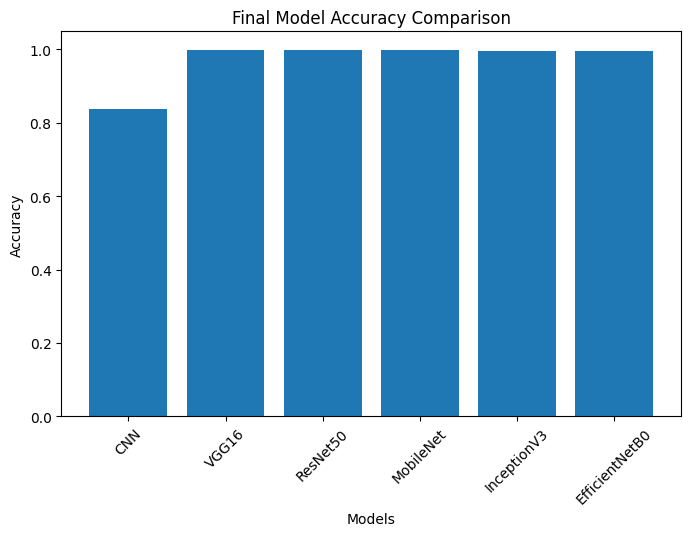

In [37]:
import matplotlib.pyplot as plt

# Collect accuracies (re-evaluating correctly)
results = {}

results["CNN"] = cnn_model.evaluate(cnn_test_generator)[1]

for name, (model_class, preprocess_func) in pretrained_models.items():
    
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    test_gen = test_datagen.flow_from_directory(
        'Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data/test',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    results[name] = trained_models[name].evaluate(test_gen)[1]

# Plot bar chart
models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Final Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

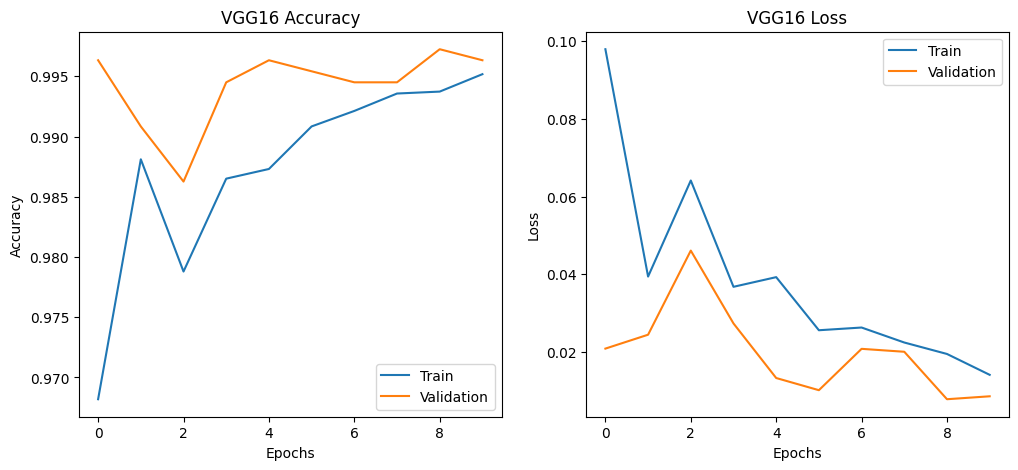

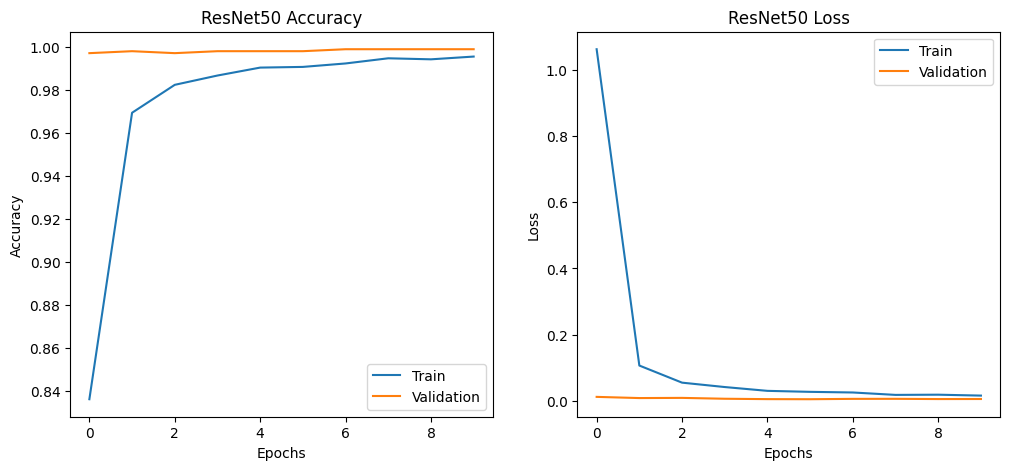

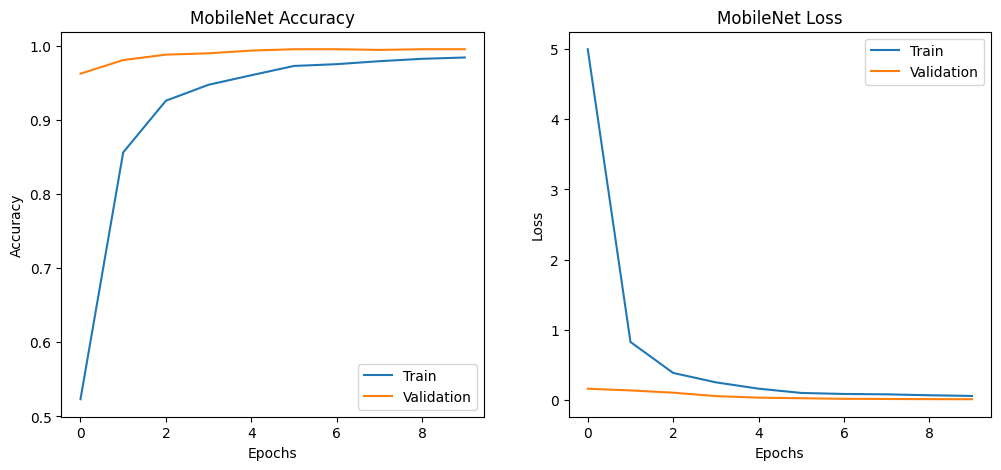

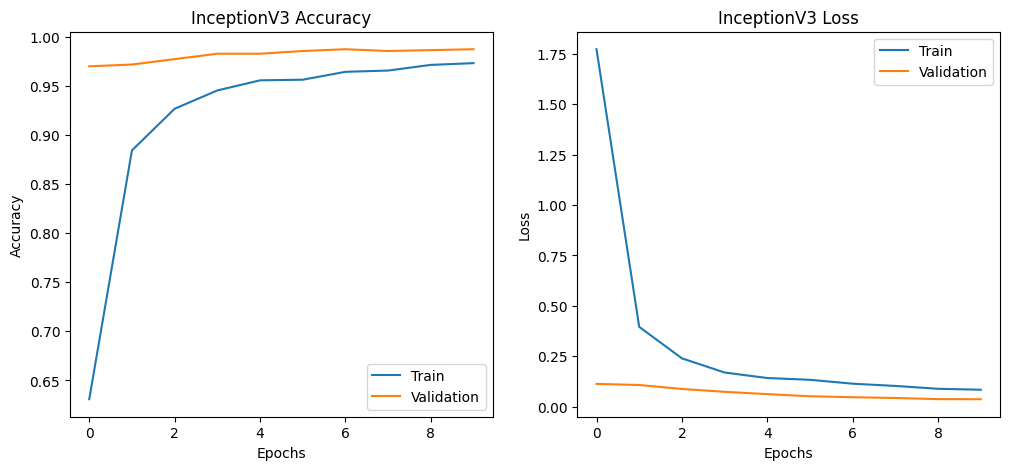

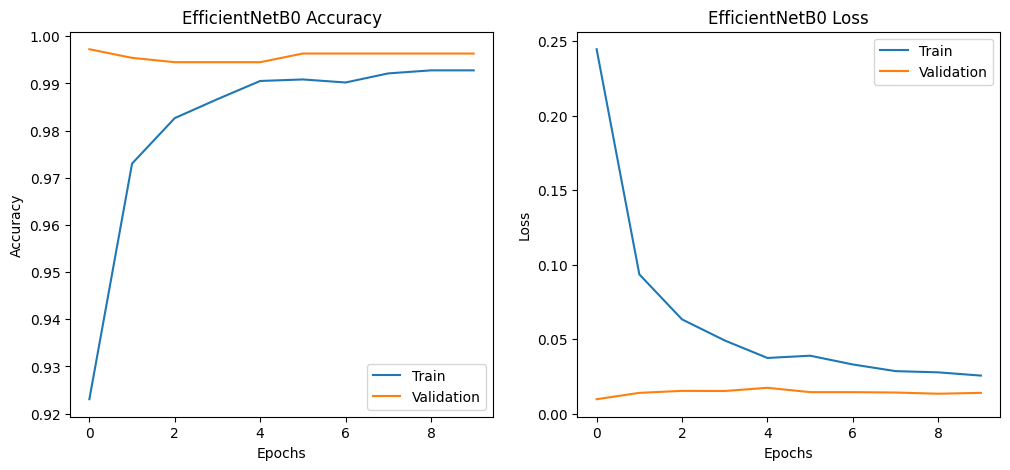

In [39]:
import matplotlib.pyplot as plt

for name, model in trained_models.items():

    history = model.history.history   # last training history (fine-tuning)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title(f"{name} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title(f"{name} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])

    plt.show()